<a href="https://colab.research.google.com/github/Veenu-Bhardwaj/BeeSkilled-Internship/blob/main/Week4_Titanic_dataset/Week4_Titanic_Survival_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset directly from the internet
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# First look at the data
print("Shape of dataset:", df.shape)
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nMissing values per column:\n", df.isnull().sum())

Shape of dataset: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450 

Missing values after cleaning:
 Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Cleaned dataset shape: (891, 8)
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  71.2833        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


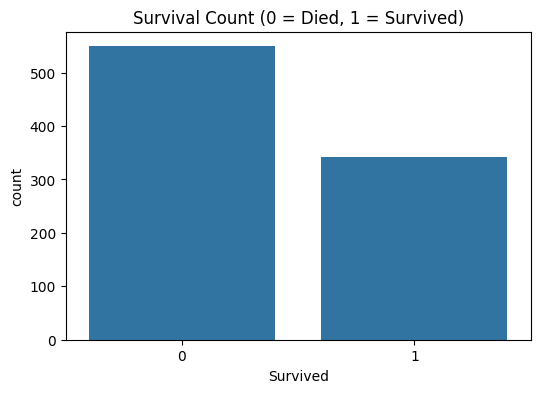

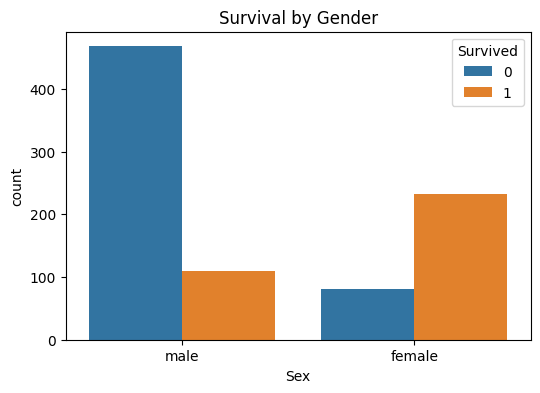

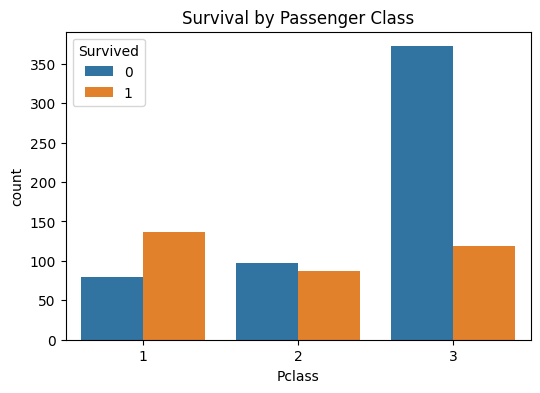

In [2]:
# ---------- CLEAN THE DATA ----------

# Fill missing Age with median age (middle value - safer than average for skewed data)
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked with the most common port
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column - too many missing values (687 out of 891) to be useful
df = df.drop("Cabin", axis=1)

# Drop columns that don't help predict survival
df = df.drop(["PassengerId", "Name", "Ticket"], axis=1)

print("Missing values after cleaning:\n", df.isnull().sum())
print("\nCleaned dataset shape:", df.shape)
print(df.head())

# ---------- EDA: SURVIVAL VISUALIZATIONS ----------

plt.figure(figsize=(6, 4))
sns.countplot(x="Survived", data=df)
plt.title("Survival Count (0 = Died, 1 = Survived)")
plt.savefig("survival_count.png")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.savefig("survival_by_gender.png")
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.savefig("survival_by_class.png")
plt.show()

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2

Model Accuracy: 0.810

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



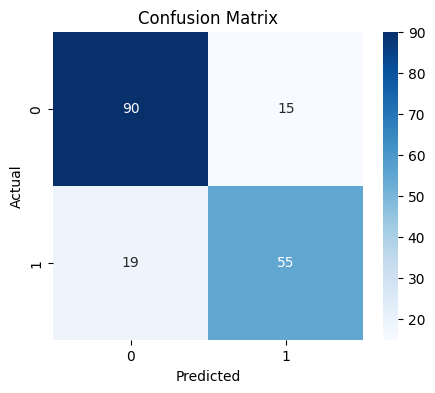

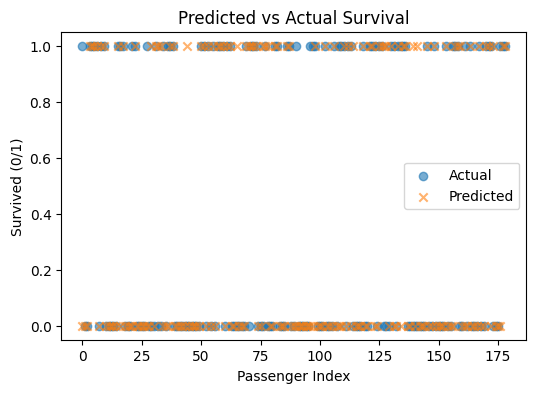

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------- ENCODE CATEGORICAL COLUMNS ----------
df_encoded = df.copy()

# Convert Sex: male=1, female=0
df_encoded["Sex"] = df_encoded["Sex"].map({"male": 1, "female": 0})

# Convert Embarked: S/C/Q into numbers
df_encoded["Embarked"] = df_encoded["Embarked"].astype("category").cat.codes

print(df_encoded.head())

# ---------- FEATURES AND TARGET ----------
X = df_encoded.drop("Survived", axis=1)
y = df_encoded["Survived"]

# ---------- TRAIN-TEST SPLIT ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------- TRAIN LOGISTIC REGRESSION MODEL ----------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ---------- PREDICT AND EVALUATE ----------
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ---------- CONFUSION MATRIX ----------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.show()

# ---------- PREDICTED VS ACTUAL PLOT ----------
plt.figure(figsize=(6, 4))
plt.scatter(range(len(y_test)), y_test, label="Actual", alpha=0.6)
plt.scatter(range(len(y_test)), y_pred, label="Predicted", alpha=0.6, marker="x")
plt.title("Predicted vs Actual Survival")
plt.xlabel("Passenger Index")
plt.ylabel("Survived (0/1)")
plt.legend()
plt.savefig("predicted_vs_actual.png")
plt.show()

## Titanic Survival Analysis — Summary Report

**Objective:** Predict passenger survival using Logistic Regression based on demographic and ticket information.

**Key Insights:**
- Female passengers had a much higher survival rate than male passengers, reflecting the "women and children first" evacuation policy.
- 1st class passengers survived at a much higher rate than 3rd class passengers, showing a strong link between wealth/class and survival chances.
- Age, fare, and number of family members aboard also influenced survival, though gender and class were the strongest predictors.

**Model Performance:**
- Model used: Logistic Regression
- Accuracy: 81%
- The model correctly identified most non-survivors and survivors, with a reasonably balanced precision and recall.

**Conclusion:** Gender and passenger class were the two most powerful predictors of survival on the Titanic.